<a href="https://colab.research.google.com/github/s4tlaw/KTH_AH2179/blob/main/AH2179_ASM4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [ ]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
#df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
df = pd.read_csv(url)
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [ ]:
df.shape

(17379, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`)
- We keep it simple; you can expand features (e.g., interactions) later.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target = 'cnt'
features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season'
]

X = df[features].copy()
y = df[target].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [ ]:
pip install tensorflow

# Library Imports

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Model Build

In [ ]:
def build_model(input_dim, dense_units=32, n_layers=2, learning_rate=1e-3):
    """Build a Sequential regression model.

    dense_units : number of neurons used in every hidden layer
    n_layers    : number of hidden Dense(relu) layers stacked
    learning_rate : Adam learning rate
    """
    model = Sequential()
    model.add(Dense(dense_units, activation='relu', input_dim=input_dim))
    for _ in range(n_layers - 1):
        model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1))  # linear output for regression
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )
    return model


def make_callbacks(checkpoint_path):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
    return [early_stop, reduce_lr, checkpoint]


# Example: a single base model run (kept from your original snippet, now with callbacks)
input_dim = X_train_scaled.shape[1]
base_model = build_model(input_dim, dense_units=32, n_layers=2, learning_rate=1e-3)
base_model.summary()

base_callbacks = make_callbacks("checkpoints/base_model.keras")

hist = base_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=base_callbacks,
    verbose=1
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 163.7638 - mae: 163.7638 - val_loss: 111.0376 - val_mae: 111.0376 - learning_rate: 0.0010
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 105.1721 - mae: 105.1721 - val_loss: 102.9743 - val_mae: 102.9743 - learning_rate: 0.0010
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 102.7913 - mae: 102.7913 - val_loss: 101.9406 - val_mae: 101.9406 - learning_rate: 0.0010
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 101.7914 - mae: 101.7914 - val_loss: 100.9662 - val_mae: 100.9662 - learning_rate: 0.0010
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 100.8536 - mae: 100.8536 - val_loss: 100.1866 - val_mae: 100.1866 - learning_rate: 0.0010
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 99.8287 - mae: 99.8287 - val_loss: 99.1023 - val_mae: 99.1023 - learning_rate: 0.0010
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 98.4303 - mae: 98.4303 - val_loss: 97

# Grid Search

In [ ]:
dense_units_grid = [16, 32, 64]
n_layers_grid = [1, 2, 4]
learning_rate_grid = [1e-2, 1e-3, 1e-4]  # high / medium / low learning-rate categories

grid_results = []
combo_id = 0
total_combos = len(dense_units_grid) * len(n_layers_grid) * len(learning_rate_grid)

for dense_units, n_layers, lr in itertools.product(dense_units_grid, n_layers_grid, learning_rate_grid):
    combo_id += 1
    print(f"\n=== Combo {combo_id}/{total_combos}: units={dense_units}, layers={n_layers}, lr={lr} ===")

    model = build_model(input_dim, dense_units=dense_units, n_layers=n_layers, learning_rate=lr)

    ckpt_path = f"checkpoints/model_units{dense_units}_layers{n_layers}_lr{lr}.keras"
    callbacks = make_callbacks(ckpt_path)

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    grid_results.append({
        "combo_id": combo_id,
        "dense_units": dense_units,
        "n_layers": n_layers,
        "learning_rate": lr,
        "epochs_trained": len(history.history["loss"]),
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "checkpoint_path": ckpt_path
    })


=== Combo 1/27: units=16, layers=1, lr=0.01 ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 101: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 117: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 136: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 141: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 147: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 157: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Epoch 162: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.

Epoch 167: ReduceLROnPlateau reducing learning rate to 3.9062499126885086e-05.
Epoch 167: early stopping
Restoring model weights from the end of the best epoch: 152.

=== Combo 2/27: units=16, layers=1, lr=0.001 ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 184: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Restoring model weights from the end of the best epoch: 200.

=== Combo 3/27: units=16, layers=1, lr=0.0001 ===


...


Epoch 39: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 57: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 47.

=== Combo 26/27: units=64, layers=4, lr=0.001 ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 57: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 62: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 67: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 52.

=== Combo 27/27: units=64, layers=4, lr=0.0001 ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 197.


# Model Comparision with metrics

In [ ]:
comparison_df = pd.DataFrame(grid_results).sort_values("MAE").reset_index(drop=True)
comparison_df.to_csv("results/grid_search_comparison_matrix.csv", index=False)

print("\nPrediction comparison matrix (sorted by MAE, best first):")
print(comparison_df[["combo_id", "dense_units", "n_layers", "learning_rate",
                      "MAE", "MSE", "R2"]].to_string(index=False))

best_row = comparison_df.iloc[0]
print(f"\nBest configuration -> units={best_row.dense_units}, "
      f"layers={best_row.n_layers}, lr={best_row.learning_rate}, "
      f"MAE={best_row.MAE:.4f}, MSE={best_row.MSE:.4f}, R2={best_row.R2:.4f}")


Prediction comparison matrix (sorted by MAE, best first):
 combo_id  dense_units  n_layers  learning_rate       MAE          MSE       R2
       25           64         4         0.0100 42.782321  4552.767080 0.856223
       16           32         4         0.0100 43.773335  4710.676989 0.851236
       22           64         2         0.0100 43.985899  4809.507749 0.848115
       26           64         4         0.0010 44.578257  4811.566931 0.848050
       17           32         4         0.0010 45.770230  5194.673515 0.835951
       27           64         4         0.0001 46.558325  5572.112485 0.824032
       13           32         2         0.0100 48.414802  5694.186651 0.820176
       23           64         2         0.0010 49.048215  6019.602638 0.809900
        7           16         4         0.0100 49.407019  5322.790669 0.831905
       14           32         2         0.0010 49.766684  6111.618399 0.806994
        8           16         4         0.0010 50.086967  59

# Ranning the best model
PS: the result vary in different run

In [ ]:
best_model = load_model(best_row.checkpoint_path)

# Re-fit briefly is not needed; ModelCheckpoint already saved the best weights
# during that combo's training. To plot the curve for the winning combo,
# retrain once more with history captured (or store histories in a dict above
# if you prefer not to retrain). Here we retrain the winning config to get its curve.

final_model = build_model(
    input_dim,
    dense_units=int(best_row.dense_units),
    n_layers=int(best_row.n_layers),
    learning_rate=float(best_row.learning_rate)
)

final_checkpoint_path = "checkpoints/best_model_overall.keras"
final_callbacks = make_callbacks(final_checkpoint_path)

final_hist = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=final_callbacks,
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 95.9122 - mae: 95.9122 - val_loss: 77.1680 - val_mae: 77.1680 - learning_rate: 0.0100
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 74.0299 - mae: 74.0299 - val_loss: 70.2769 - val_mae: 70.2769 - learning_rate: 0.0100
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.0139 - mae: 68.0139 - val_loss: 60.4519 - val_mae: 60.4519 - learning_rate: 0.0100
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 60.1465 - mae: 60.1465 - val_loss: 57.7250 - val_mae: 57.7250 - learning_rate: 0.0100
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 57.2339 - mae: 57.2339 - val_loss: 53.3855 - val_mae: 53.3855 - learning_rate: 0.0100
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54.4925 - mae: 54.4925 - val_loss: 53.3030 - val_mae: 53.3030 - learning_rate: 0.0100
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 53.0849 - mae: 53.0849 - val_loss: 51.1997 - val_mae: 51.1997 - learn

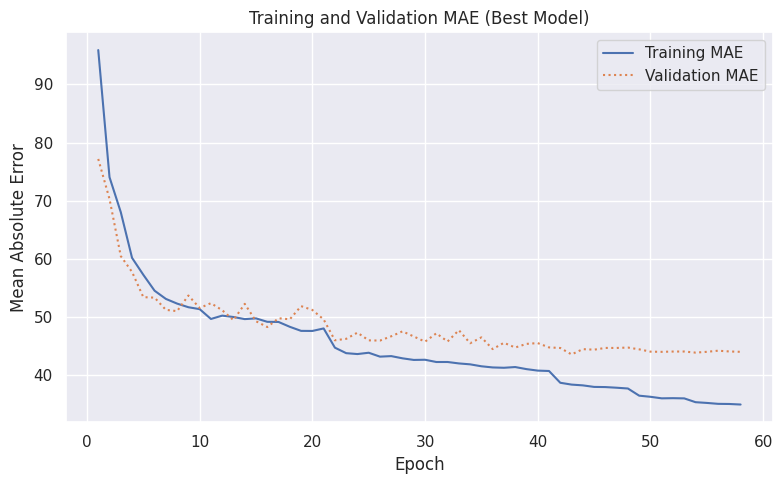


Final best model test metrics: {'MAE': 43.321183362956425, 'MSE': 4595.682950885932, 'R2': 0.8548674166251908}

Best model saved to: checkpoints/best_model_overall.keras


In [ ]:

sns.set()
err = final_hist.history['mae']
val_err = final_hist.history['val_mae']
epochs_range = range(1, len(err) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, err, '-', label='Training MAE')
plt.plot(epochs_range, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE (Best Model)')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("results/best_model_training_curve.png", dpi=150)
plt.show()

# Final predictions from the best model
y_pred_best = final_model.predict(X_test_scaled, verbose=0).flatten()

final_metrics = {
    "MAE": mean_absolute_error(y_test, y_pred_best),
    "MSE": mean_squared_error(y_test, y_pred_best),
    "R2": r2_score(y_test, y_pred_best)
}
print("\nFinal best model test metrics:", final_metrics)

# Best model is already saved to disk via ModelCheckpoint (final_checkpoint_path).
# Optionally save again explicitly in native Keras format:
final_model.save("checkpoints/best_model_overall_explicit_save.keras")
print(f"\nBest model saved to: {final_checkpoint_path}")

# History comparsion
hist: units=32, layers=2, lr=0.001

history: units=64, layers=4, lr=0.0001 (last grid combo by loop order)

final_hist: units=64, layers=4, lr=0.01 (grid-search winner's hyperparameters)

Found histories: ['hist', 'history', 'final_hist']


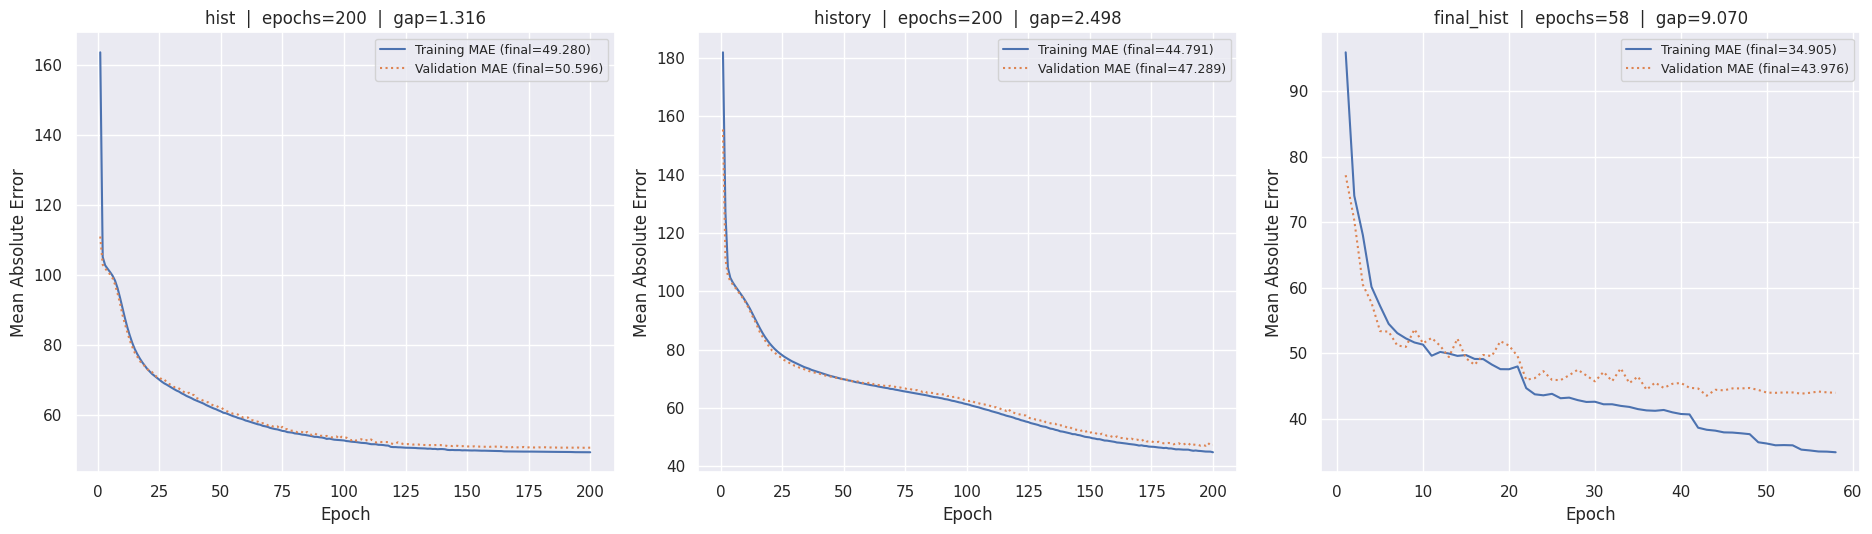

  variable  epochs_trained  final_train_mae  final_val_mae  val_minus_train_gap
final_hist              58        34.905457      43.975662             9.070206
   history             200        44.791100      47.288830             2.497730
      hist             200        49.279991      50.595722             1.315731


In [ ]:
sns.set()

candidates = {}
for name in ['hist', 'history', 'final_hist']:
    if name in globals():
        candidates[name] = globals()[name]

print("Found histories:", list(candidates.keys()))

fig, axes = plt.subplots(1, len(candidates), figsize=(6.3 * len(candidates), 5.5))
if len(candidates) == 1:
    axes = [axes]

summary_rows = []

for ax, (name, h) in zip(axes, candidates.items()):
    err = h.history['mae']
    val_err = h.history['val_mae']
    epochs_range = range(1, len(err) + 1)

    train_final = err[-1]
    val_final = val_err[-1]
    gap = val_final - train_final

    ax.plot(epochs_range, err, '-', label=f'Training MAE (final={train_final:.3f})')
    ax.plot(epochs_range, val_err, ':', label=f'Validation MAE (final={val_final:.3f})')
    ax.set_title(f'{name}  |  epochs={len(err)}  |  gap={gap:.3f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Absolute Error')
    ax.legend(loc='upper right', fontsize=9)

    summary_rows.append({
        'variable': name,
        'epochs_trained': len(err),
        'final_train_mae': train_final,
        'final_val_mae': val_final,
        'val_minus_train_gap': gap
    })

plt.tight_layout()
plt.savefig('three_histories_comparison.png', dpi=150)
plt.show()

# Printed numeric summary to accompany the chart
import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values('final_val_mae').reset_index(drop=True)
print(summary_df.to_string(index=False))

# Save to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
